In [4]:
import pandas as pd
import os
PROJECT_PATH = f"/home/{os.getenv('USER')}/project1ml4h/"
df_a = pd.read_parquet(PROJECT_PATH + "data/processed/set_a.parquet")
df_b = pd.read_parquet(PROJECT_PATH + "data/processed/set_b.parquet")
df_c = pd.read_parquet(PROJECT_PATH + "data/processed/set_c.parquet")

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ID_COLS = ["PatientID", "Time"]
BINARY_COLS = ["Gender", "MechVent", "label"]
STATIC_CONT_COLS = ["Age", "Height", "Weight_static"]
DYNAMIC_COLS = [
    "ALP", "ALT", "AST", "Albumin", "BUN", "Bilirubin", "Cholesterol",
    "Creatinine", "DiasABP", "FiO2", "GCS", "Glucose", "HCO3", "HCT",
    "HR", "K", "Lactate", "MAP", "Mg", "NIDiasABP", "NIMAP", "NISysABP",
    "Na", "PaCO2", "PaO2", "Platelets", "RespRate", "SaO2", "SysABP",
    "Temp", "TroponinI", "TroponinT", "Urine", "WBC", "Weight", "pH"
]

def make_summary_table(df):
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "non_null": s.notna().sum(),
            "missing": s.isna().sum(),
            "missing_pct": 100 * s.isna().mean(),
            "n_unique": s.nunique(dropna=True),
            "min": s.min() if pd.api.types.is_numeric_dtype(s) else None,
            "q25": s.quantile(0.25) if pd.api.types.is_numeric_dtype(s) else None,
            "median": s.median() if pd.api.types.is_numeric_dtype(s) else None,
            "q75": s.quantile(0.75) if pd.api.types.is_numeric_dtype(s) else None,
            "max": s.max() if pd.api.types.is_numeric_dtype(s) else None,
            "mean": s.mean() if pd.api.types.is_numeric_dtype(s) else None,
            "std": s.std() if pd.api.types.is_numeric_dtype(s) else None,
        })
    summary = pd.DataFrame(rows).sort_values("missing_pct", ascending=False)
    return summary

def plot_missingness(summary_df):
    temp = summary_df.sort_values("missing_pct", ascending=True)

    plt.figure(figsize=(10, max(6, len(temp) * 0.25)))
    plt.barh(temp["column"], temp["missing_pct"])
    plt.xlabel("Missingness (%)")
    plt.ylabel("Column")
    plt.title("Missingness by column")
    plt.tight_layout()
    plt.show()

def plot_binary_column(df, col):
    counts = df[col].value_counts(dropna=False).sort_index()

    plt.figure(figsize=(6, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Value counts for {col}")
    plt.tight_layout()
    plt.show()

def plot_continuous_distribution(df, col, log_scale=False):
    s = df[col].dropna()

    if len(s) == 0:
        print(f"{col}: all values are missing")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(s, bins=40)
    axes[0].set_title(f"{col} histogram")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    axes[1].boxplot(s, vert=True)
    axes[1].set_title(f"{col} boxplot")
    axes[1].set_ylabel(col)

    if log_scale:
        positive_s = s[s > 0]
        if len(positive_s) > 0:
            axes[0].cla()
            axes[0].hist(np.log10(positive_s), bins=40)
            axes[0].set_title(f"{col} histogram (log10, positive values only)")
            axes[0].set_xlabel(f"log10({col})")
            axes[0].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

def plot_time_profile(df, col):
    temp = df.groupby("Time")[col].agg(
        mean="mean",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count"
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(temp["Time"], temp["mean"], label="Mean")
    axes[0].plot(temp["Time"], temp["median"], label="Median")
    axes[0].fill_between(temp["Time"], temp["q25"], temp["q75"], alpha=0.3, label="IQR")
    axes[0].set_title(f"{col} over time")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel(col)
    axes[0].legend()

    axes[1].bar(temp["Time"], temp["count"])
    axes[1].set_title(f"{col} observed values by hour")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Non-missing count")

    plt.tight_layout()
    plt.show()

def plot_random_patient_trajectories(df, col, n_patients=10, seed=42):
    valid_ids = df.loc[df[col].notna(), "PatientID"].unique()
    if len(valid_ids) == 0:
        print(f"{col}: no observed values")
        return

    rng = np.random.default_rng(seed)
    chosen = rng.choice(valid_ids, size=min(n_patients, len(valid_ids)), replace=False)

    plt.figure(figsize=(10, 5))
    for pid in chosen:
        sub = df[df["PatientID"] == pid]
        plt.plot(sub["Time"], sub[col], alpha=0.7)

    plt.xlabel("Hour")
    plt.ylabel(col)
    plt.title(f"{col}: random patient trajectories")
    plt.tight_layout()
    plt.show()

def exploratory_analysis(df):
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    summary = make_summary_table(df)
    print("\nSummary table:")
    print(summary)

    return summary

In [10]:
summary_a = exploratory_analysis(df_a)

Shape: (196000, 44)

Columns:
['PatientID', 'Time', 'Age', 'Gender', 'Height', 'Weight_static', 'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH', 'label']

Summary table:
           column    dtype  non_null  missing  missing_pct  n_unique  \
12    Cholesterol  float64       315   195685    99.839286       140   
37      TroponinI  float64       435   195565    99.778061       163   
38      TroponinT  float64      2122   193878    98.917347       451   
9         Albumin  float64      2353   193647    98.799490        41   
6             ALP  float64      3086   192914    98.425510       386   
7             ALT  float64      3171   192829    98.382143       752   
8             AST  float64   

In [6]:
df_a.head()

,PatientID,Time,Age,Gender,Height,Weight_static,ALP,ALT,AST,Albumin,...,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH,label
0,132539,0,54.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,132539,1,54.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN,0
2,132539,2,54.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,0
3,132539,3,54.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,0
4,132539,4,54.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,37.8,NaN,NaN,60.0,NaN,NaN,NaN,0


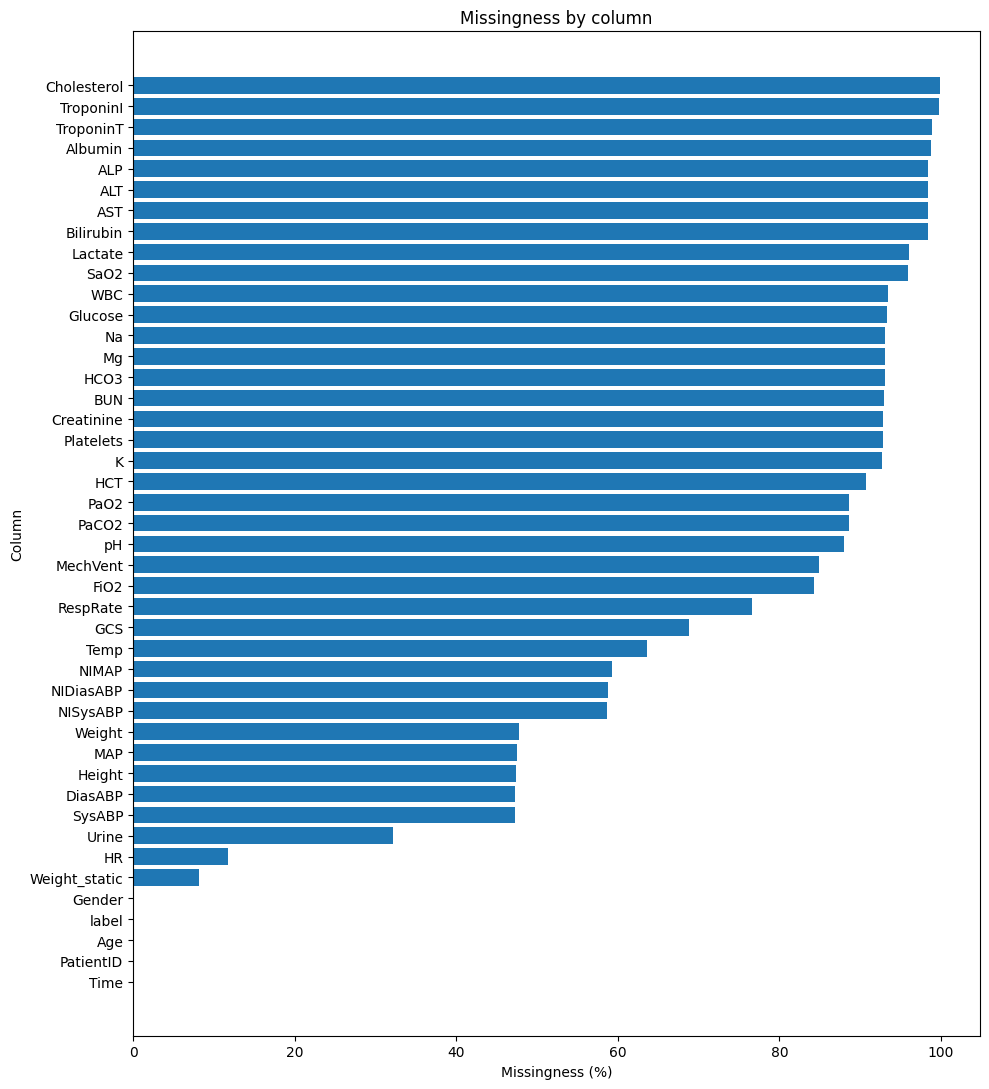

In [11]:
plot_missingness(summary_a)

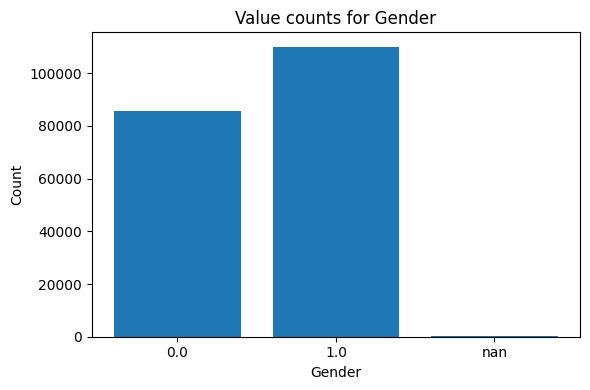

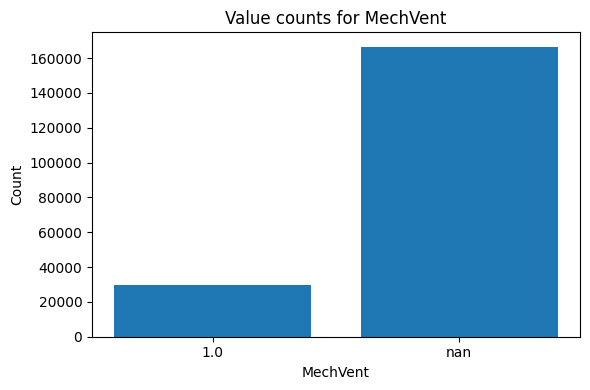

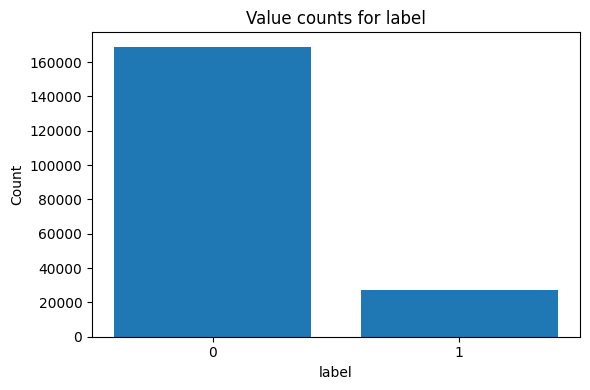

In [12]:
for col in ["Gender", "MechVent", "label"]:
    plot_binary_column(df_a, col)

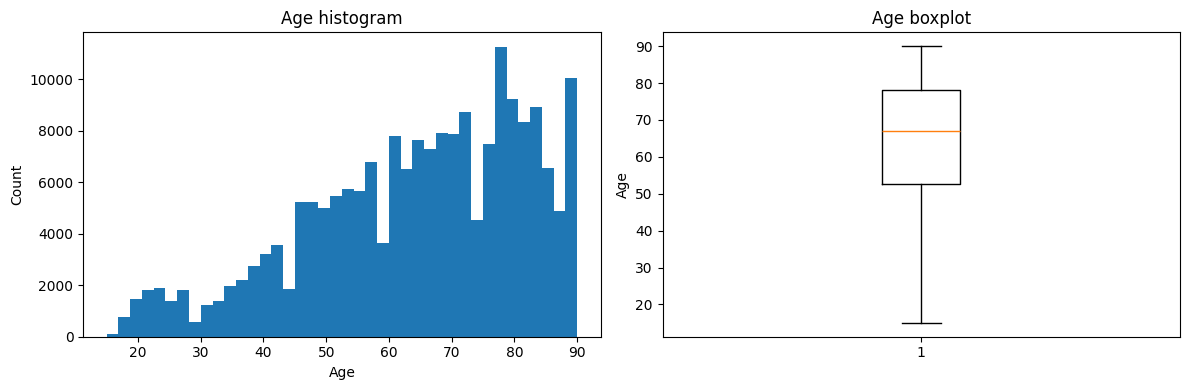

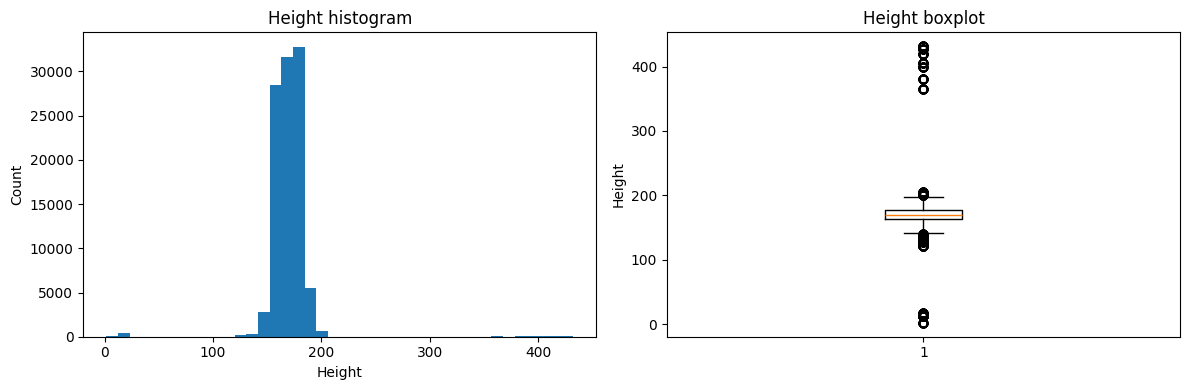

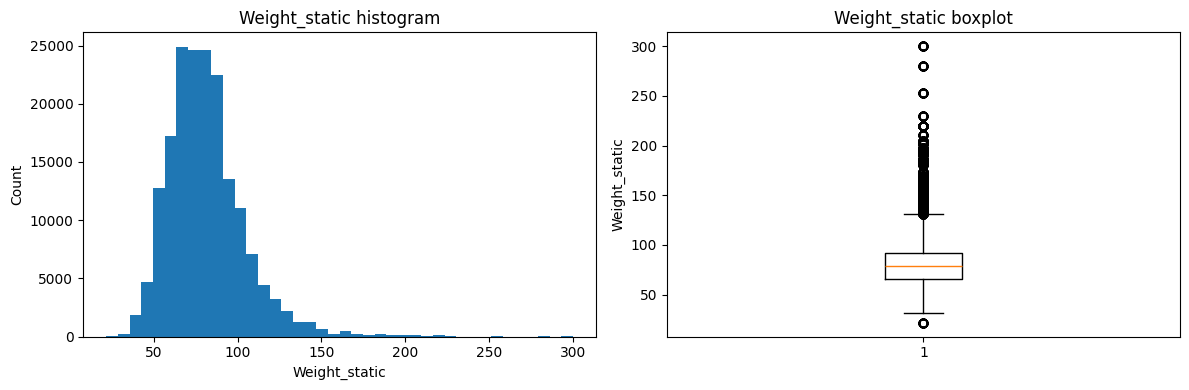

In [13]:
for col in ["Age", "Height", "Weight_static"]:
    plot_continuous_distribution(df_a, col)

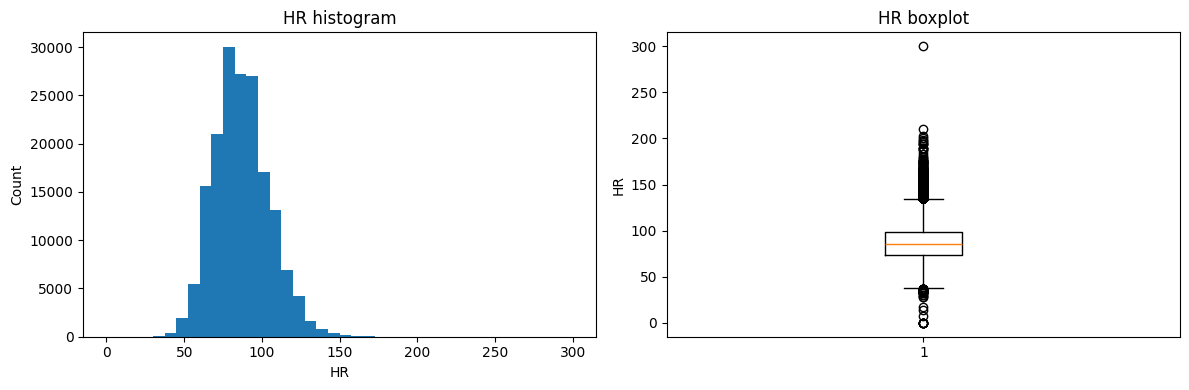

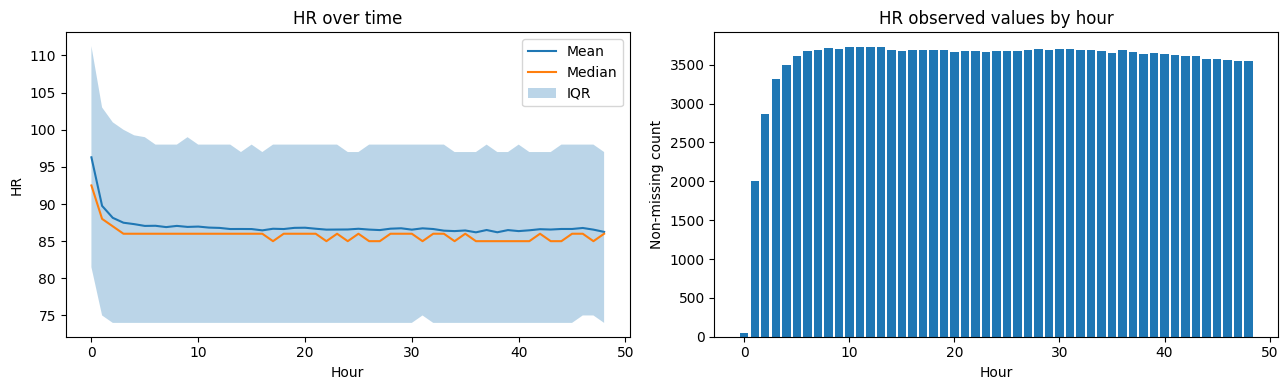

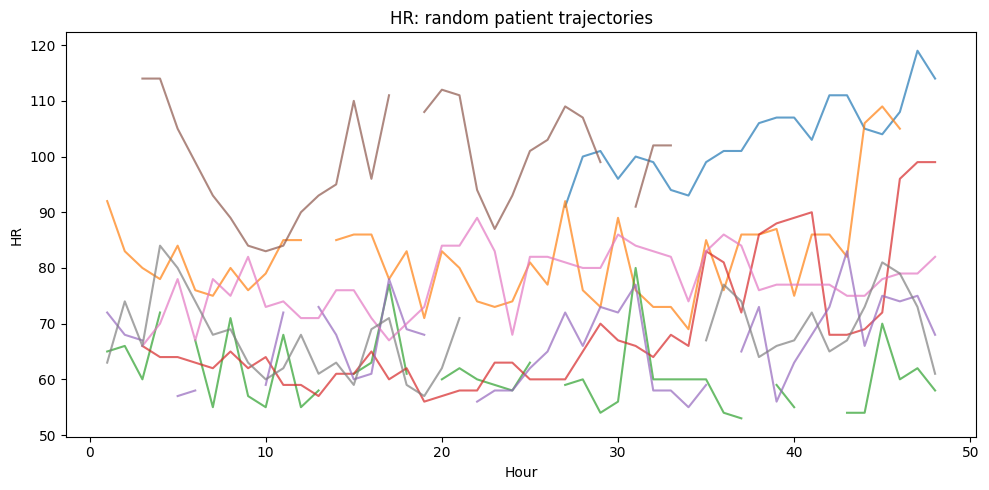

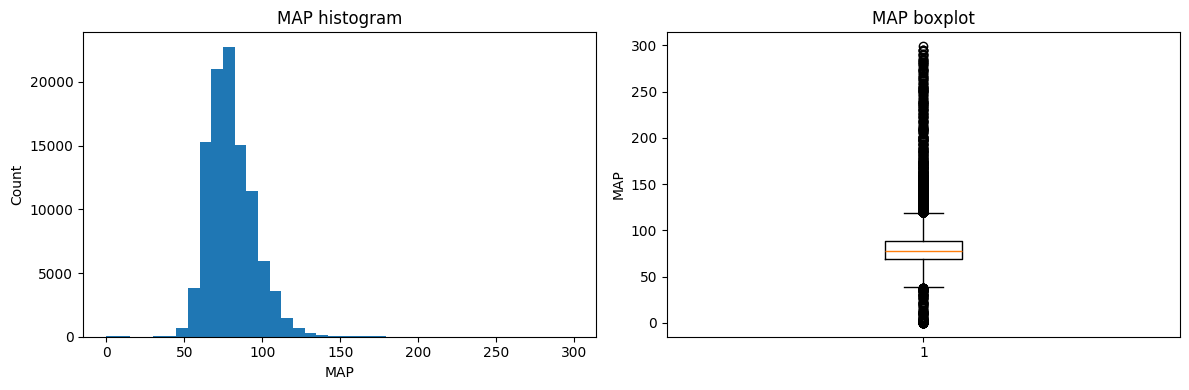

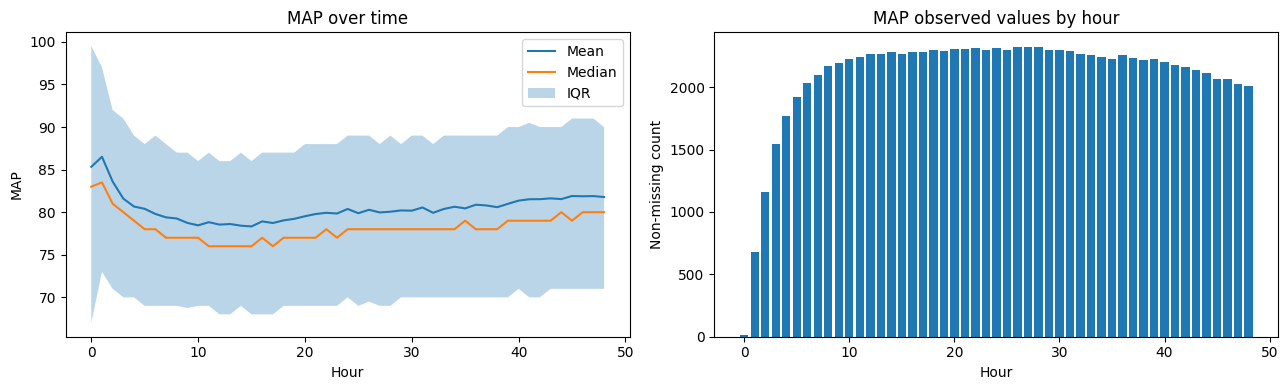

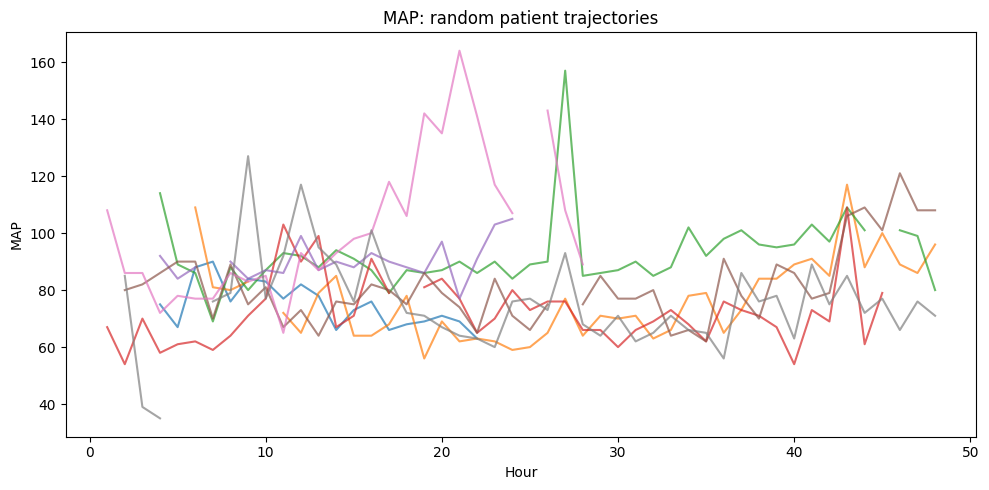

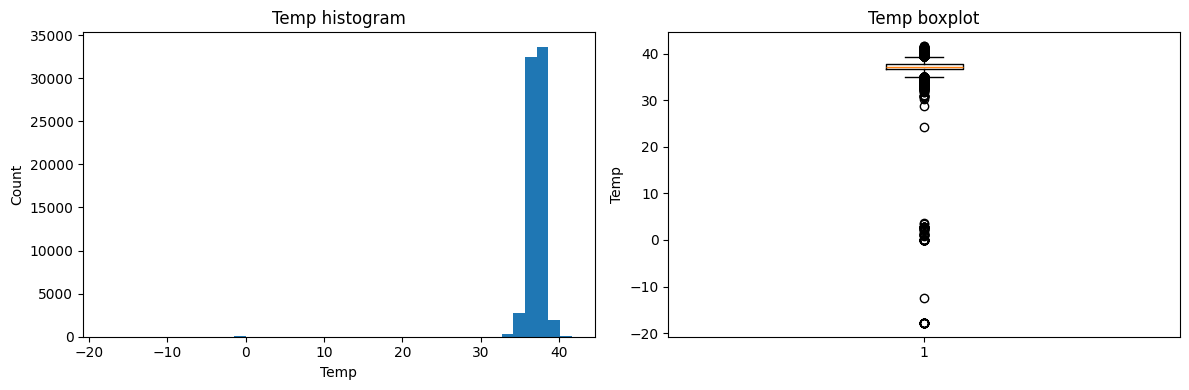

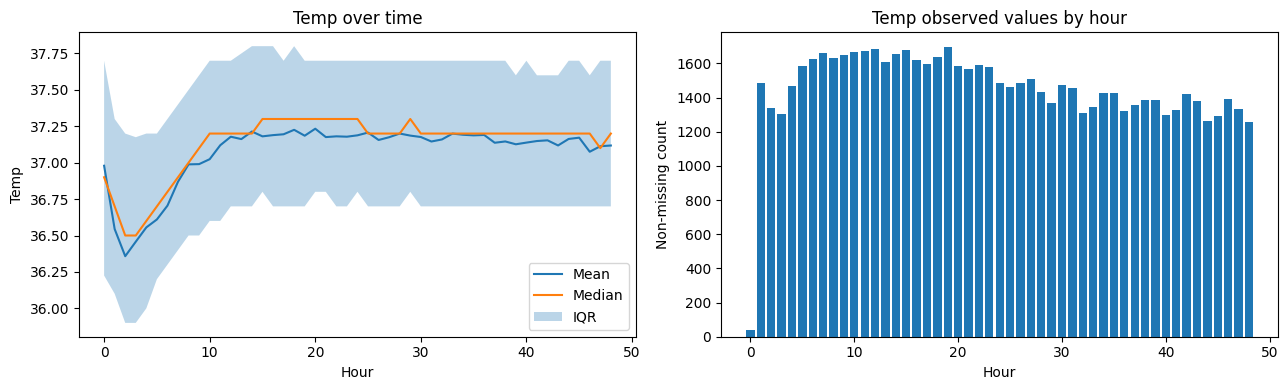

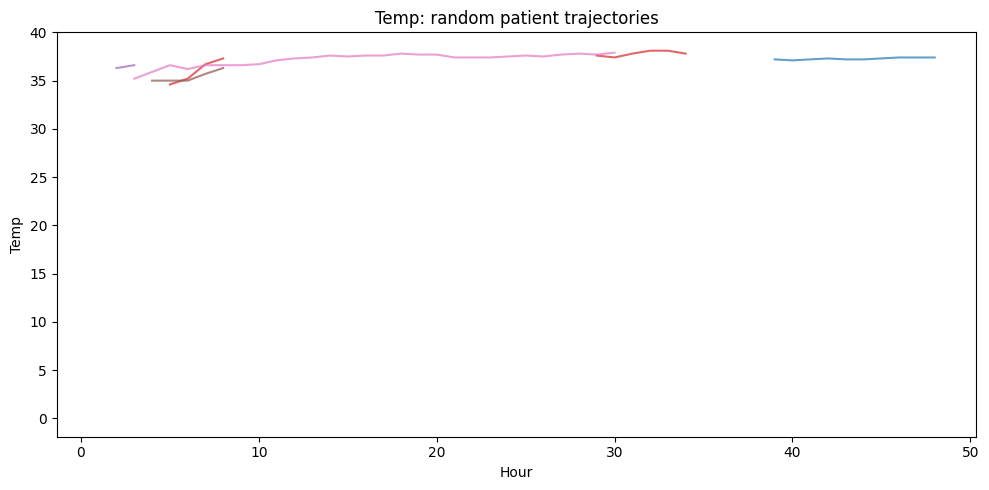

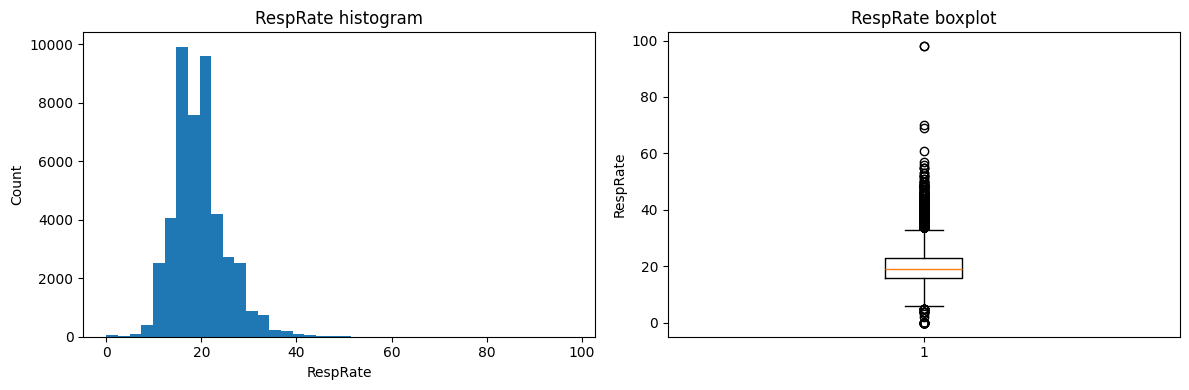

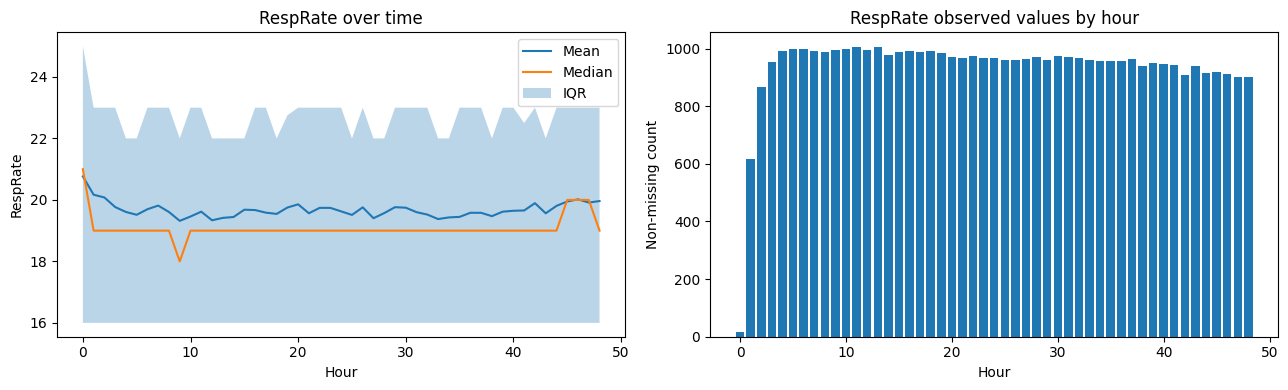

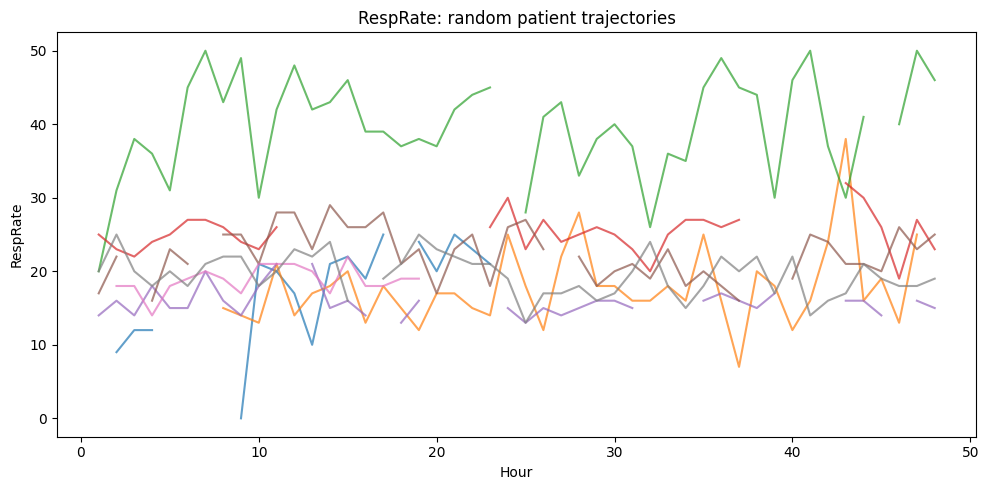

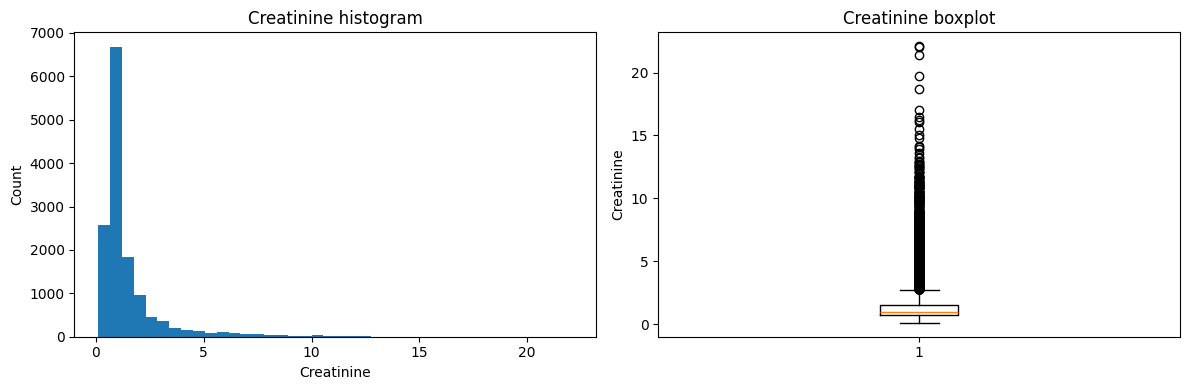

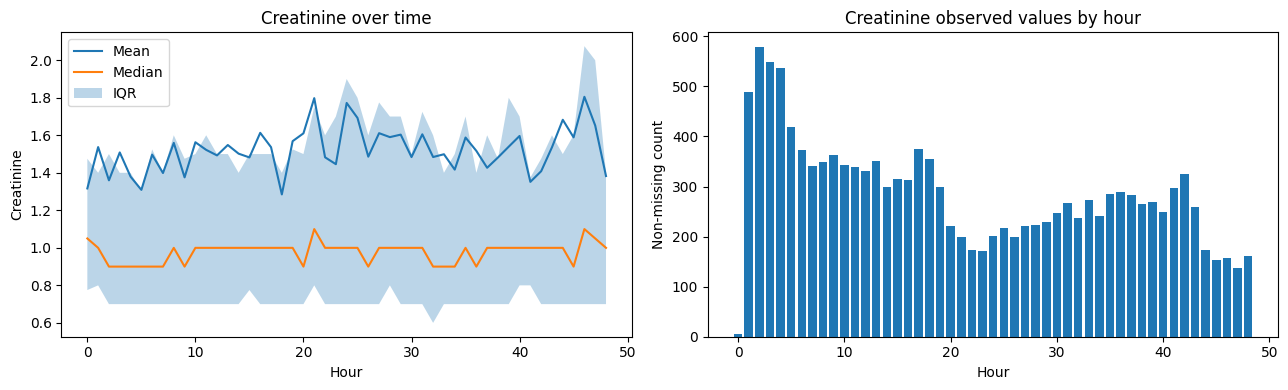

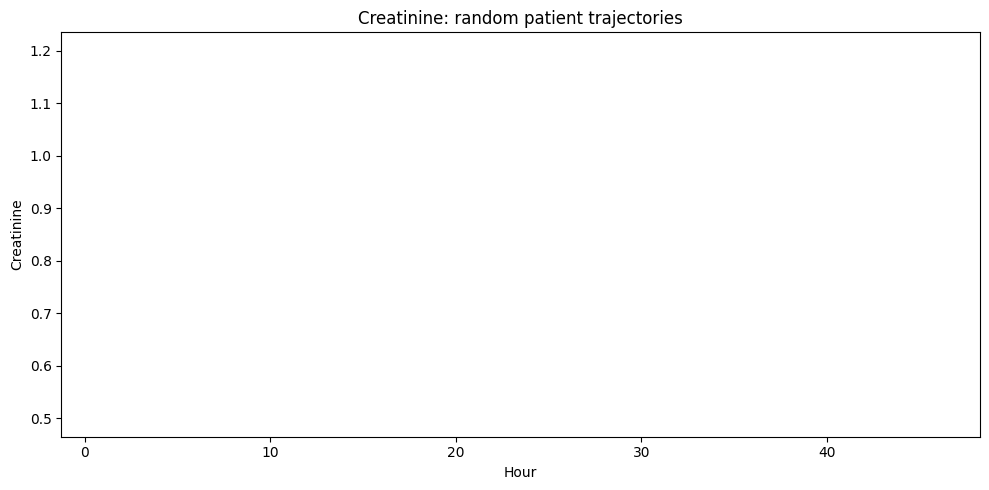

In [14]:
for col in ["HR", "MAP", "Temp", "RespRate", "Creatinine"]:
    plot_continuous_distribution(df_a, col)
    plot_time_profile(df_a, col)
    plot_random_patient_trajectories(df_a, col, n_patients=8)

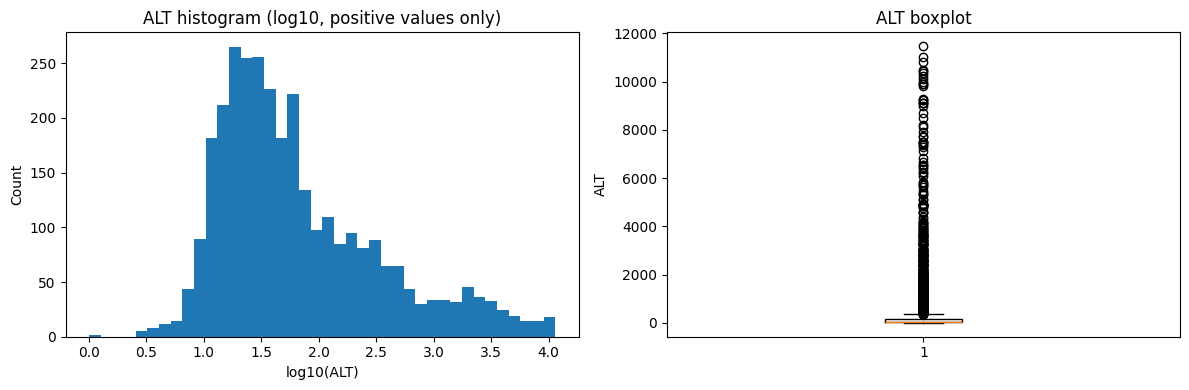

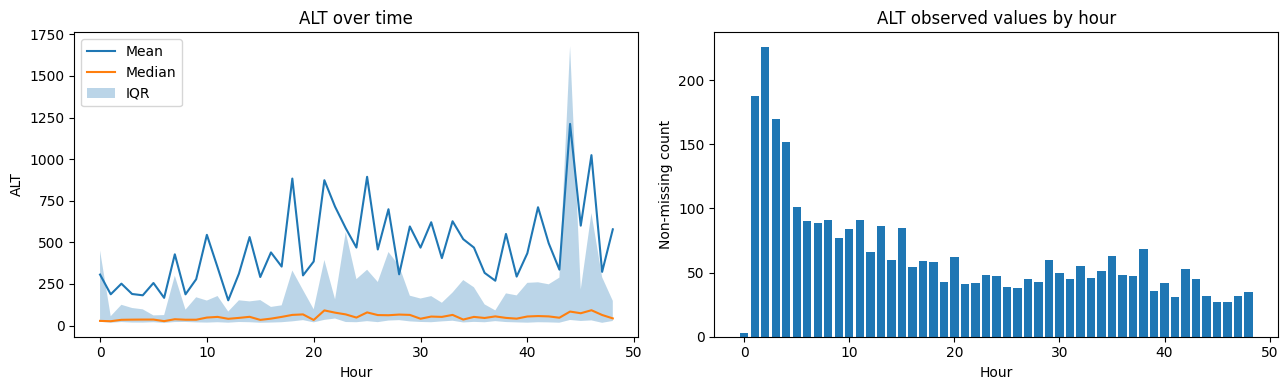

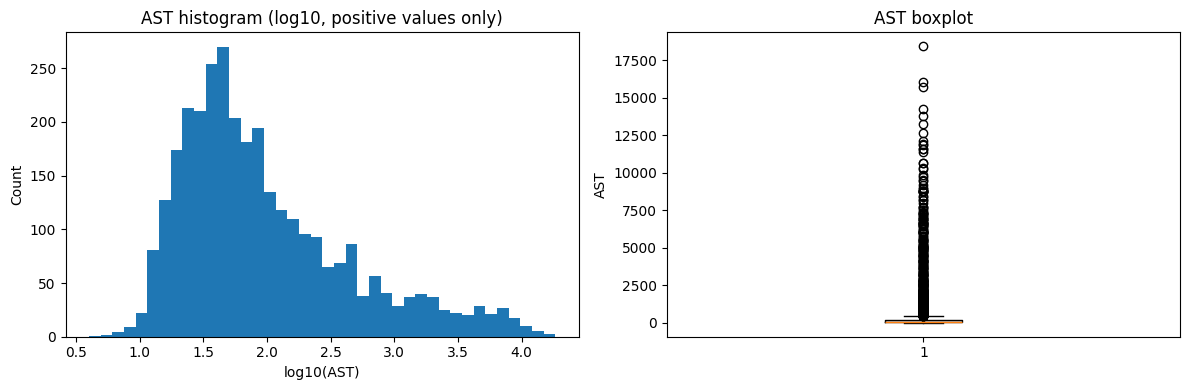

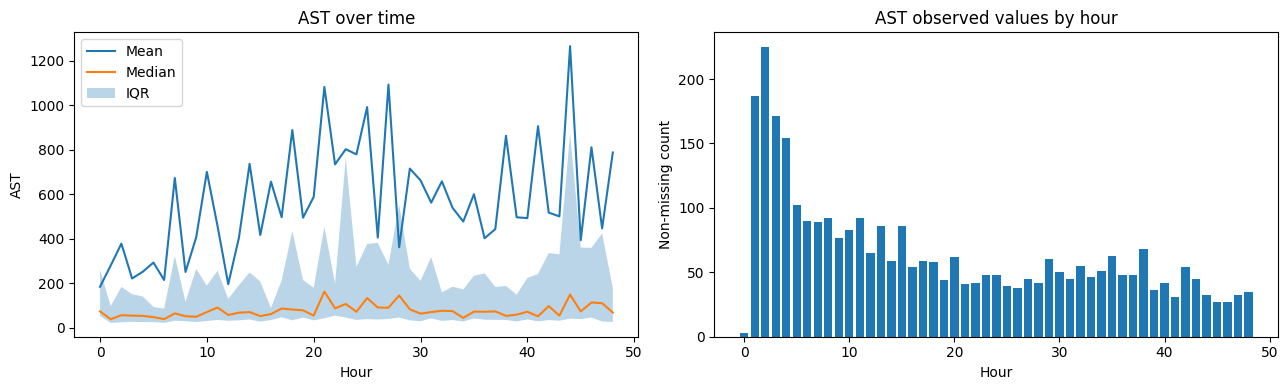

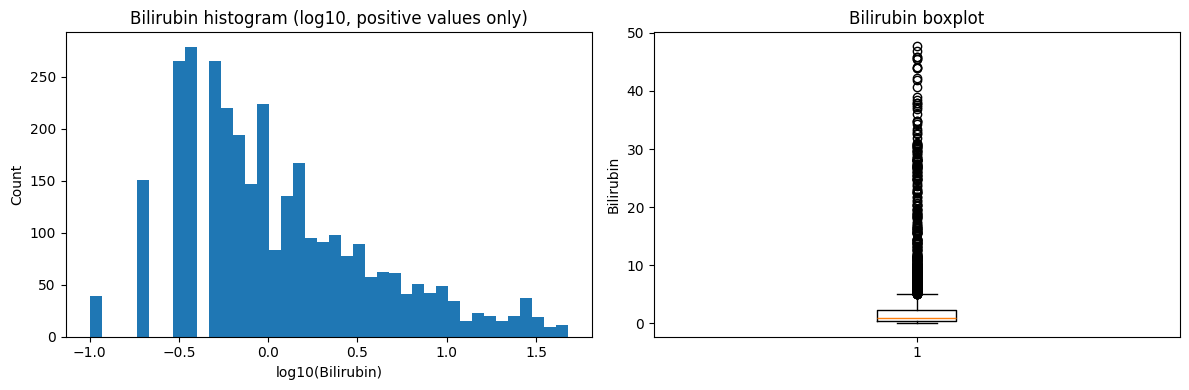

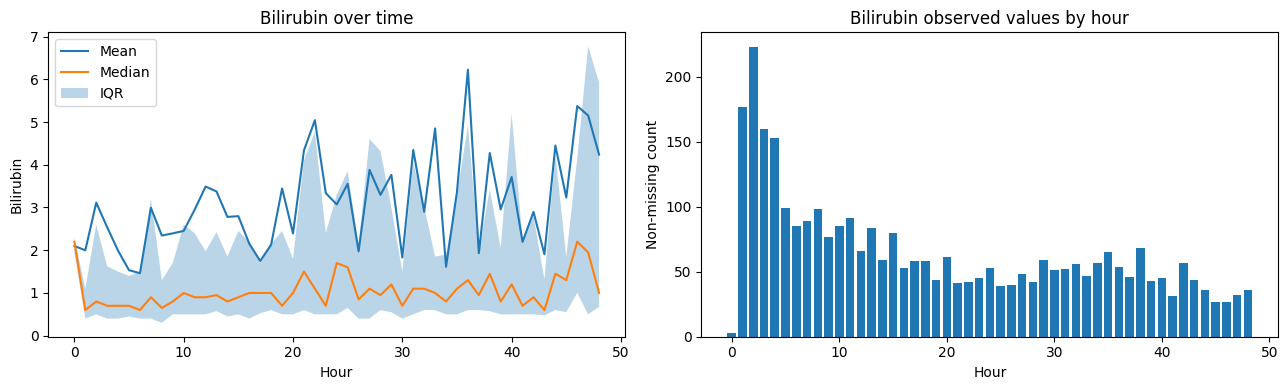

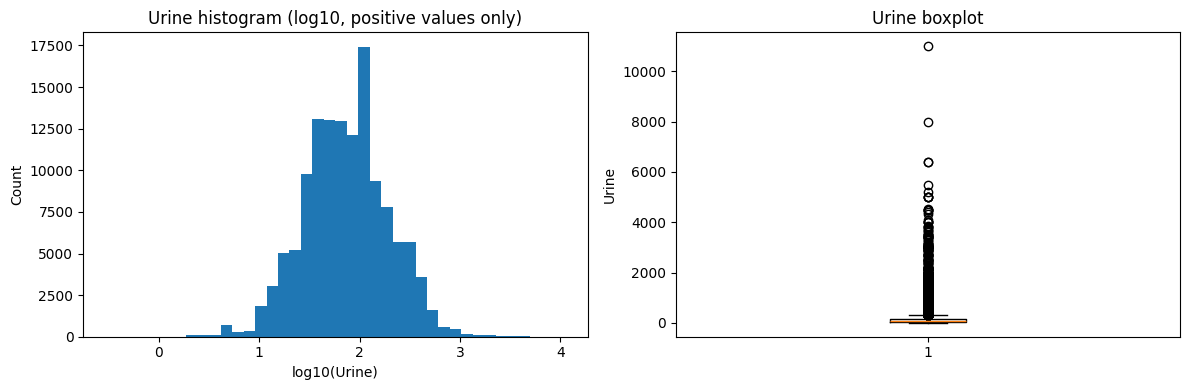

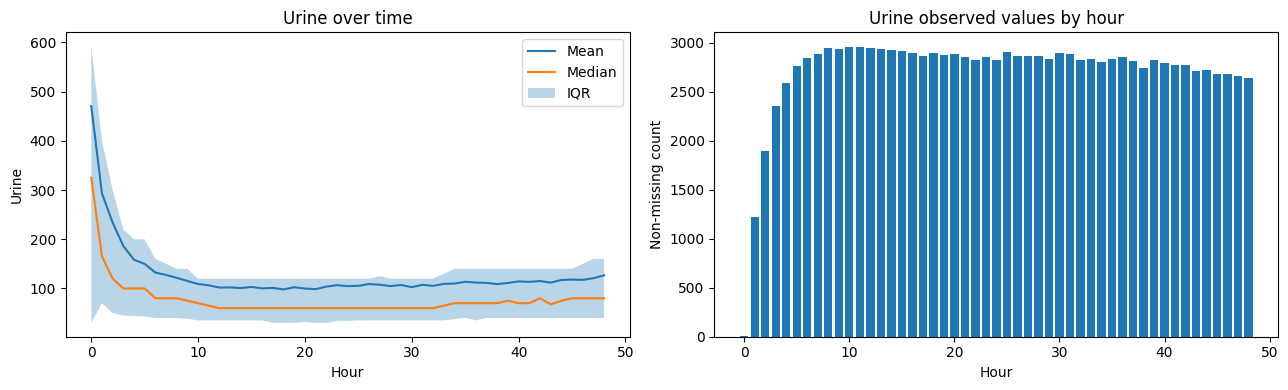

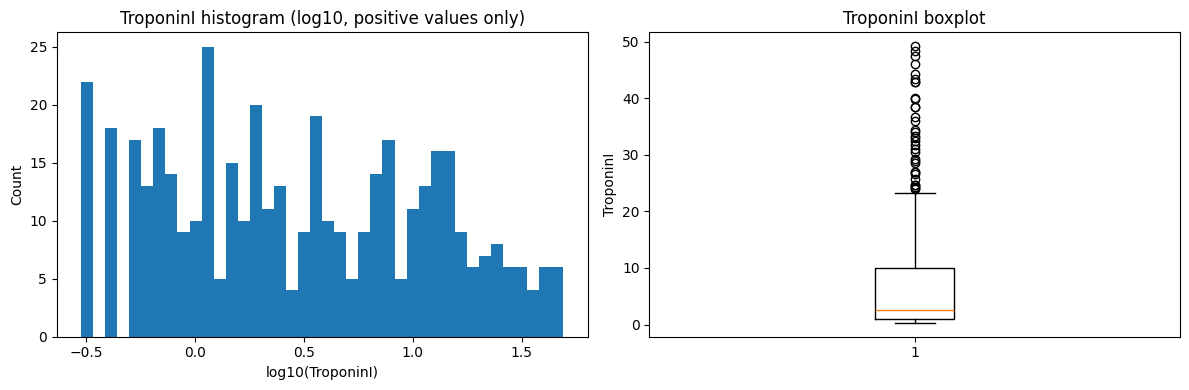

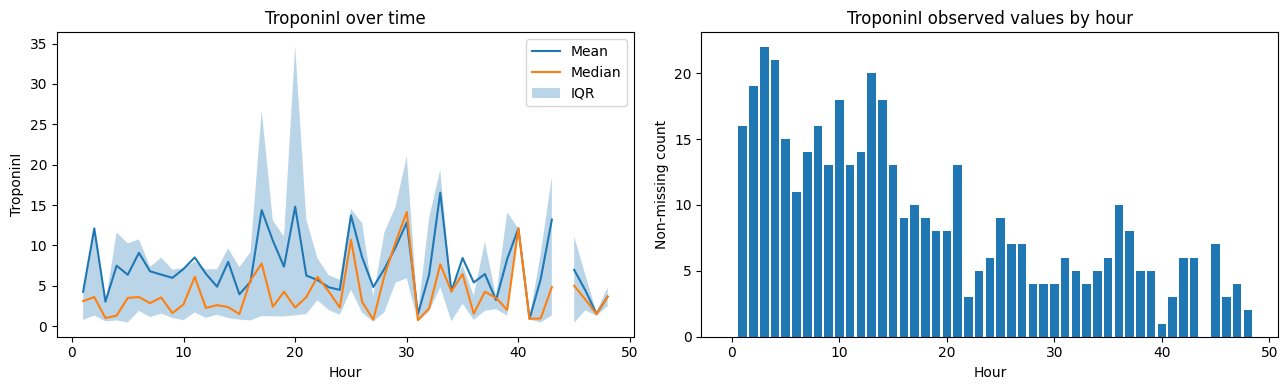

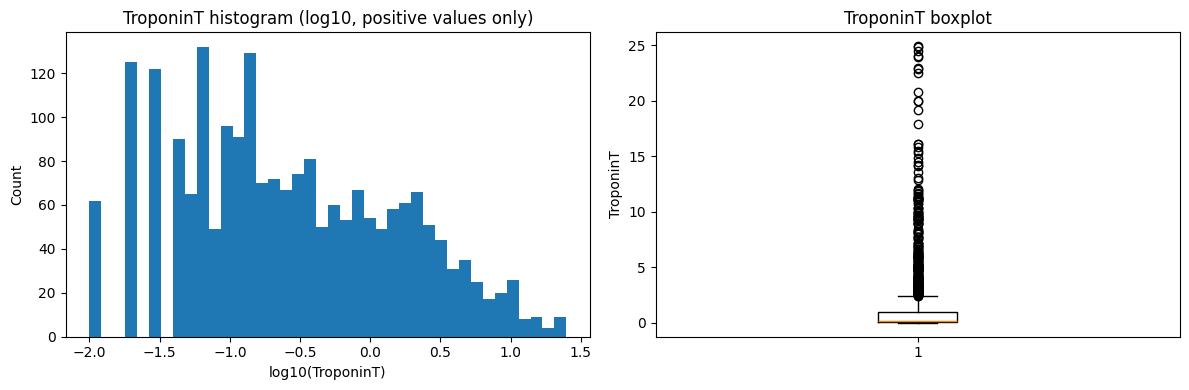

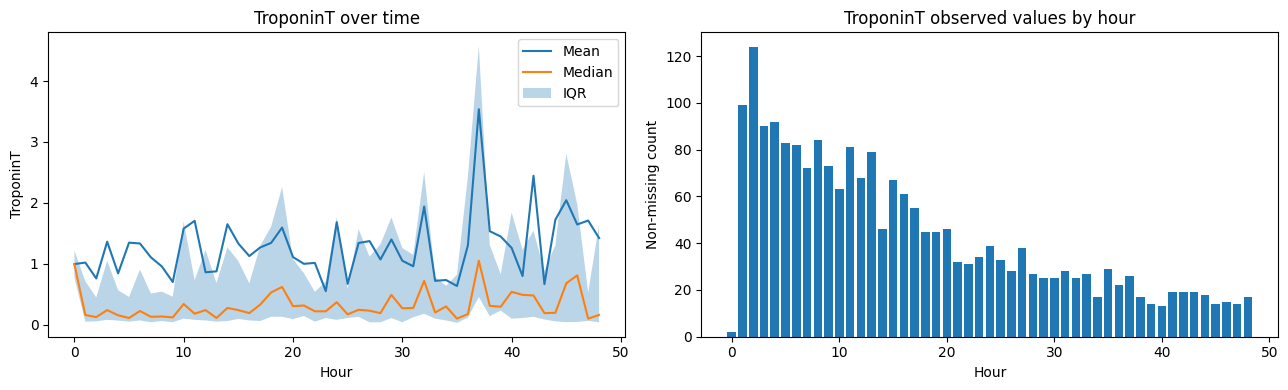

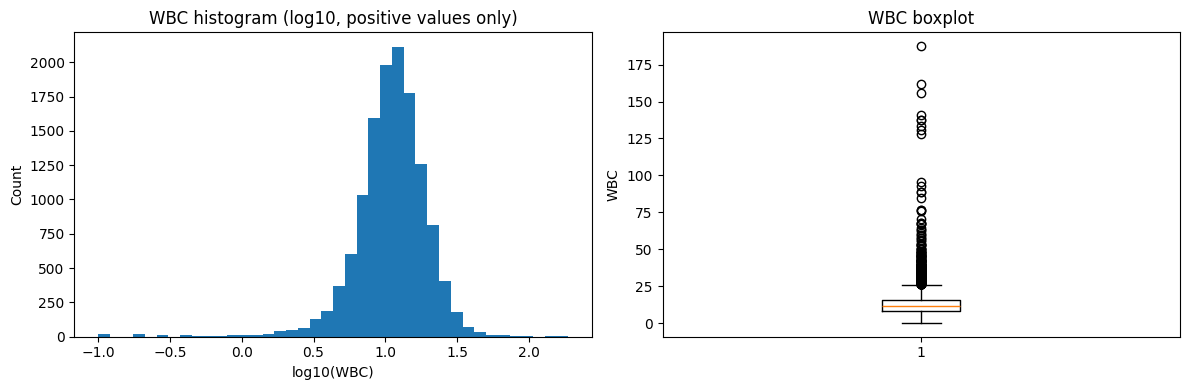

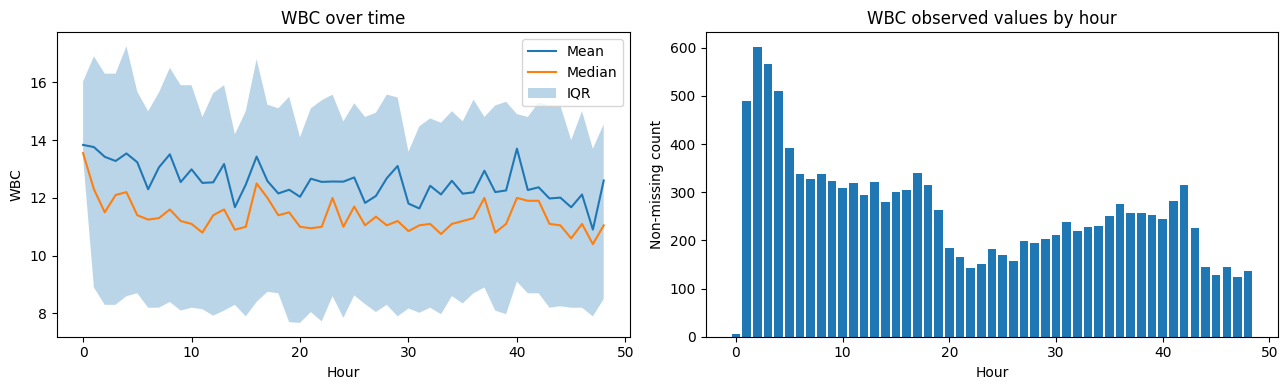

In [15]:
for col in ["ALT", "AST", "Bilirubin", "Urine", "TroponinI", "TroponinT", "WBC"]:
    plot_continuous_distribution(df_a, col, log_scale=True)
    plot_time_profile(df_a, col)